### Data Processing

This study integrates three primary data sources: the CDC/ATSDR Social Vulnerability Index (SVI) 2018 county-level dataset, FEMA Individuals and Households Program (IHP) 2018-2020 disaster assistance records, and U.S. county 2018 boundary geometries used for spatial modeling. The objective of the preprocessing pipeline is to construct a consistent county-level dataset that links social vulnerability indicators with observed disaster assistance outcomes while preserving geographic structure. The SVI dataset serves as the foundation of the analytic sample. County Federal Information Processing Standard (FIPS) codes were standardized to five-digit strings to ensure consistent geographic identifiers across datasets. FEMA IHP records were then processed to produce county-level disaster assistance totals. Because FEMA records contain one row per disaster declaration and county, the IHP assistance amounts were aggregated by county FIPS code to compute the total disaster assistance received during 2018-2020. Prior to aggregation, FIPS codes were cleaned and converted to five-digit strings to maintain compatibility with the SVI dataset. 

After aggregation, FEMA assistance totals were merged with the SVI dataset using county FIPS codes. A left join was used so that the SVI dataset defines the universe of counties used in the analysis. Counties that did not appear in the FEMA dataset were assigned a total assistance value of zero. This treatment is appropriate because the absence of FEMA IHP records indicates that no Individual and Households Program assistance was recorded for that county during the study period rather than representing missing data.

During validation of the merge, a discrepancy was observed between the FEMA and SVI county lists. Specifically, FEMA contained 3,127 unique county-level FIPS codes, while the SVI dataset contained 3,142 counties. Further inspection revealed that **77 FEMA county-equivalent codes were not present in the SVI dataset**. Examination of the state prefixes associated with these codes showed that the majority corresponded to Puerto Rico municipios (prefix 72) and U.S. Virgin Islands counties (prefix 78). A small number of additional mismatches were attributable to **county-equivalent jurisdictions or historical code changes**, including an Alaska census area code, the District of Columbia, a Virginia independent city, and a South Dakota county-equivalent. These mismatches arise because FEMA disaster declarations include **U.S. territories and certain county-equivalent jurisdictions**, whereas the SVI dataset used in this study primarily represents U.S. counties and county equivalents within the standard SVI county coverage. Rather than attempting to reconcile these jurisdictional differences, the analysis restricts the study domain to counties present in the SVI dataset. FEMA records associated with territories or other unmatched jurisdictions are therefore excluded implicitly during the merge process. This approach ensures that the analytic sample remains geographically consistent with the SVI indicators and the county boundary dataset used for spatial analysis.

Following the FEMA merge, county geometries were attached using a county boundary dataset derived from the 2018 U.S. Census TIGER/Line shapefiles. County FIPS codes were constructed from state and county identifiers within the shapefile and standardized to the same five-digit format used in the SVI and FEMA datasets. The SVI–FEMA dataset was then merged with the county geometries using an inner join on FIPS codes. The resulting dataset was converted to a GeoDataFrame to support spatial operations and graph-based modeling.

At the conclusion of these preprocessing steps, each county in the analytic dataset contains a consistent geographic identifier, a set of SVI vulnerability indicators, aggregated FEMA IHP disaster assistance totals for the 2018–2020 period, and the county geometry required for constructing spatial adjacency relationships. This processed dataset forms the basis for the feature matrix and target variable used in the subsequent EDA and modeling stages.

In [1]:
#| output: false

import sys
from pathlib import Path

# Set to root for src load
root = Path.cwd()
while root != root.parent and not (root / "src").exists():
    root = root.parent

if not (root / "src").exists():
    raise FileNotFoundError("Could not find 'src' folder above current working directory.")

sys.path.insert(0, str(root))
print("Project root:", root)

Project root: c:\Users\joetn\CS273P_MachineLearning_Final_Project


In [2]:
# Standard library
import json
import requests

# Third-party libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd

from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Local imports
from src.eda import (
    choose_k_gap_rule,
    evaluate_kmeans_k,
    fit_kmeans,
    pca_project,
    plot_clusters_pca,
    plot_k_diagnostics,
)

# Plot configuration
plt.rcParams.update(
    {
        "font.size": 9,
        "axes.titlesize": 10,
        "axes.labelsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "legend.fontsize": 8,
        "legend.title_fontsize": 9,
        "legend.frameon": True,
        "legend.borderpad": 0.3,
    }
)

In [3]:
#| output: false

# Data directories
RAW_DATA_DIR = Path("../data/raw")
PROCESSED_DATA_DIR = Path("../data/processed")
SVI_PATH = RAW_DATA_DIR / "SVI_2018_US_county.csv"
SHAPE_PATH = RAW_DATA_DIR / "tl_2018_us_county/tl_2018_us_county.shp"

# Load svi.csv
svi = pd.read_csv(SVI_PATH)

# Load county lines
counties = gpd.read_file(SHAPE_PATH)

In [4]:
#| output: false

# OPTION A: RUN THIS TO LOAD FROM API (THIS WILL TAKE A LONG TIME)
# OPTION B: DOWNLOAD DIRECTLY FROM GOOGLE DRIVE ZIP FILE & PLACE INTO DATA/RAW: 

# OPTION A: Load FEMA 2018-2020 target from OpenFEMA API
# BASE_URL = "https://www.fema.gov/api/open/v2/IndividualsAndHouseholdsProgramValidRegistrations"

# SELECT_FIELDS = [
#     "fips",
#     "ihpAmount",
# ]

# FILTER = (
#     "declarationDate ge '2018-01-01T00:00:00.000Z' and "
#     "declarationDate le '2020-12-31T23:59:59.999Z'"
# )

# records = []
# top = 1000
# skip = 0

# while True:
#     params = {
#         "$select": ",".join(SELECT_FIELDS),
#         "$filter": FILTER,
#         "$top": top,
#         "$skip": skip,
#     }

#     response = requests.get(BASE_URL, params=params, timeout=60)
#     response.raise_for_status()

#     batch = response.json()["IndividualsAndHouseholdsProgramValidRegistrations"]

#     if not batch:
#         break

#     records.extend(batch)

#     if len(batch) < top:
#         break

#     skip += top

# fema = pd.DataFrame(records)

# print("FEMA rows loaded:", len(fema))
# print(fema.columns.tolist())
# display(fema.head())

# # Path to save raw FEMA data
# FEMA_RAW_PATH = DATA_DIR / "fema_ihp_2018_2020_raw.csv"

# # Save raw API results
# fema.to_csv(FEMA_RAW_PATH, index=False)

# print(f"Saved FEMA raw data to: {FEMA_RAW_PATH}")


In [5]:
#| output: false

# Load raw fema
FEMA_PATH = RAW_DATA_DIR / "fema_ihp_2018_2020_raw.csv"
fema = pd.read_csv(FEMA_PATH)

# Drop unneccessary columns if any
fema = fema.drop(columns=["declarationDate", "disaster_count"], errors="ignore")

# Fill missing with 0s
fema["ihpAmount"] = pd.to_numeric(fema["ihpAmount"], errors="coerce").fillna(0)

# Aggregate by county fips
fema_county = (
    fema
    .groupby("fips", as_index=False)
    .agg(
        total_ihp=("ihpAmount", "sum")
    )
)

# Standardize FIPS
fema_county["fips"] = (
    fema_county["fips"]
    .astype(float)
    .astype(int)
    .astype(str)
    .str.zfill(5)
)

FEMA_PROCESSED_PATH = PROCESSED_DATA_DIR / "fema_ihp_2018_2020_county.csv"

fema_county.to_csv(FEMA_PROCESSED_PATH, index=False)

print(fema_county.shape)
fema_county.head()


(3127, 2)


,fips,total_ihp
0,01001,681589.20
1,01003,25254957.79
2,01005,380843.19
3,01007,76369.22
4,01009,191912.48


In [6]:
#| output: false

print(svi.shape)
svi.head()

(3142, 123)


,ST,STATE,ST_ABBR,COUNTY,FIPS,LOCATION,AREA_SQMI,E_TOTPOP,M_TOTPOP,E_HU,...,F_CROWD,F_NOVEH,F_GROUPQ,F_THEME4,F_TOTAL,E_UNINSUR,M_UNINSUR,EP_UNINSUR,MP_UNINSUR,E_DAYPOP
0,35,NEW MEXICO,NM,Rio Arriba,35039,"Rio Arriba County, New Mexico",5860.869195,39307,0,20044,...,0,0,0,1,-999,4160,588,10.6,1.5,32290
1,1,ALABAMA,AL,Autauga,1001,"Autauga County, Alabama",594.443459,55200,0,23315,...,0,0,0,0,0,3875,508,7.1,0.9,37301
2,1,ALABAMA,AL,Blount,1009,"Blount County, Alabama",644.830460,57645,0,24222,...,0,0,0,0,0,6303,732,11.0,1.3,40036
3,1,ALABAMA,AL,Butler,1013,"Butler County, Alabama",776.838201,20025,0,10026,...,0,0,0,0,0,2005,340,10.2,1.7,17280
4,1,ALABAMA,AL,Calhoun,1015,"Calhoun County, Alabama",605.867251,115098,0,53682,...,0,0,0,0,0,10686,796,9.4,0.7,117894


In [7]:
#| output: false

print(counties.shape)
counties.head()

(3233, 18)


,STATEFP,COUNTYFP,COUNTYNS,GEOID,NAME,NAMELSAD,LSAD,CLASSFP,MTFCC,CSAFP,CBSAFP,METDIVFP,FUNCSTAT,ALAND,AWATER,INTPTLAT,INTPTLON,geometry
0,31,039,00835841,31039,Cuming,Cuming County,06,H1,G4020,NaN,NaN,NaN,A,1477652222,10690952,+41.9158651,-096.7885168,"POLYGON ((-97.01952 42.0041, -97.01952 42.0049..."
1,53,069,01513275,53069,Wahkiakum,Wahkiakum County,06,H1,G4020,NaN,NaN,NaN,A,680956809,61588406,+46.2946377,-123.4244583,"POLYGON ((-123.43639 46.2382, -123.44759 46.24..."
2,35,011,00933054,35011,De Baca,De Baca County,06,H1,G4020,NaN,NaN,NaN,A,6016819484,29089486,+34.3592729,-104.3686961,"POLYGON ((-104.56739 33.99757, -104.56772 33.9..."
3,31,109,00835876,31109,Lancaster,Lancaster County,06,H1,G4020,339,30700,NaN,A,2169287528,22832516,+40.7835474,-096.6886584,"POLYGON ((-96.91075 40.78494, -96.91075 40.790..."
4,31,129,00835886,31129,Nuckolls,Nuckolls County,06,H1,G4020,NaN,NaN,NaN,A,1489645187,1718484,+40.1764918,-098.0468422,"POLYGON ((-98.27367 40.0894, -98.27367 40.0894..."


In [8]:
# Standardize FIPS in svi
svi["FIPS"] = svi["FIPS"].astype(str).str.zfill(5)

# Clean and aggregate FEMA to county level
fema["fips"] = pd.to_numeric(fema["fips"], errors="coerce")
fema["ihpAmount"] = pd.to_numeric(fema["ihpAmount"], errors="coerce").fillna(0)

fema = fema.dropna(subset=["fips"]).copy()
fema["fips"] = fema["fips"].astype(int).astype(str).str.zfill(5)

fema_county = (
    fema.groupby("fips", as_index=False)
    .agg(
        total_ihp=("ihpAmount", "sum")
    )
)

# Merge FEMA into svi first
df = (
    svi.merge(
        fema_county,
        left_on="FIPS",
        right_on="fips",
        how="left"
    )
    .drop(columns=["fips"])
)

# Fill counties with no FEMA IHP records as zero
df["total_ihp"] = df["total_ihp"].fillna(0)

# Build FIPS in counties
counties["FIPS"] = (
    counties["STATEFP"].astype(str) +
    counties["COUNTYFP"].astype(str)
).str.zfill(5)

# Extract geometry
counties_c = counties[["FIPS", "geometry"]]

# Merge SVI data with geometry
geo_df = df.merge(
    counties_c,
    on="FIPS",
    how="inner"
).sort_values("FIPS").reset_index(drop=True)

# Convert to GeoDataFrame
geo_df = gpd.GeoDataFrame(geo_df, geometry="geometry")


In [9]:
#| output: false

# Data validation
display(pd.DataFrame({
    "dataset": ["svi", "fema_raw", "fema_county", "df (svi+fema_county)", "geo_df (df + geometry)"],
    "rows": [
        svi.shape[0],
        fema.shape[0],
        fema_county.shape[0],
        df.shape[0],
        geo_df.shape[0]
    ],
    "columns": [
        svi.shape[1],
        fema.shape[1],
        fema_county.shape[1],
        df.shape[1],
        geo_df.shape[1]
    ]
}))


,dataset,rows,columns
0,svi,3142,123
1,fema_raw,1432057,3
2,fema_county,3127,2
3,df (svi+fema_county),3142,124
4,geo_df (df + geometry),3142,125


In [10]:
#| output: false

# Data validation
display(pd.DataFrame({
    "metric": ["counties_with_ihp", "counties_without_ihp"],
    "value": [
        (df["total_ihp"] > 0).sum(),
        (df["total_ihp"] == 0).sum()
    ]
}))


,metric,value
0,counties_with_ihp,3035
1,counties_without_ihp,107


In [11]:
#| output: false

# Data validation
missing_svi = sorted(set(fema_county["fips"]) - set(svi["FIPS"]))

display(pd.DataFrame({
    "metric": [
        "fema_counties",
        "svi_counties",
        "fema_not_in_svi_count"
    ],
    "value": [
        fema_county["fips"].nunique(),
        svi["FIPS"].nunique(),
        len(missing_svi)
    ]
}))


,metric,value
0,fema_counties,3127
1,svi_counties,3142
2,fema_not_in_svi_count,77


In [12]:
#| output: false

# State prefix for the 77 from FEMA missing in SVI
missing_svi_df = pd.DataFrame({"FIPS": missing_svi})
missing_svi_df["state_prefix"] = missing_svi_df["FIPS"].str[:2]

display(
    missing_svi_df["state_prefix"]
    .value_counts()
    .rename_axis("state_prefix")
    .reset_index(name="count")
)


,state_prefix,count
0,72,71
1,78,2
2,02,1
3,11,1
4,46,1
5,51,1


In [13]:
# Define overall target
target = ["total_ihp"]

# Define percentage indicators (EP_*)
feature_cols_ep = [
    # Theme 1:
    "EP_POV",
    "EP_UNEMP",
    "EP_PCI",   
    "EP_NOHSDP",
    
    # Theme 2:
    "EP_AGE65",
    "EP_AGE17",
    "EP_DISABL",
    "EP_SNGPNT",
    
    # Theme 3:
    "EP_MINRTY",
    "EP_LIMENG",
    
    # Theme 4:
    "EP_MUNIT",
    "EP_MOBILE",
    "EP_CROWD",
    "EP_NOVEH",
    "EP_GROUPQ"
]

# Build modeling dataset with identity preserved for downstream GCN models
model_df = geo_df[["FIPS"] + feature_cols_ep + target].copy()

# Feature matrix (do not change row indices beyond this)
X = model_df[feature_cols_ep].copy()

# Target matrix (do not change row indices beyond this)
y = model_df[target].copy()

# Exploratory Data Analysis (EDA)

Exploratory data analysis (EDA) is conducted to examine the statistical and spatial characteristics of the Social Vulnerability Index (SVI) indicators and FEMA disaster assistance outcomes prior to model development. Because the objective of this study is to evaluate whether county-level vulnerability indicators are associated with the distribution of disaster assistance, it is important to first understand the distributions and relationships present in the data. EDA helps identify issues such as skewed feature distributions, multicollinearity among predictors, and spatial variability across regions.

A summary of the processed datasets used for EDA and modeling is presented in @tbl-svi-data-summary. This includes the modeling dataset (`model_df`), feature matrix (`X`), target variable (`y`), and spatial geometry dataset (`geo_df`) used for constructing the geographic graph.

The analytic dataset contains 3,144 U.S. counties, with 15 SVI percentage indicators (`EP_*`) used as predictors and county-level FEMA Individuals and Households Program (IHP) disaster assistance totals from 2018–2020 used as the prediction target. All datasets contain consistent data types and no missing values.

The exploratory analysis focuses on two components: **target variable exploration** and **feature matrix exploration**.

In [14]:
#| label: tbl-svi-data-summary
#| tbl-cap: "Summary of the modeling datasets used in this study. The modeling dataset (model_df) contains 3,144 U.S. counties with county identifiers, 15 socioeconomic and demographic indicators derived from the CDC Social Vulnerability Index (SVI), and the aggregated FEMA Individuals and Households Program (IHP) disaster assistance totals for the 2018–2020 study period. The feature matrix (X) contains the 15 SVI indicators used as predictors. The target matrix (y) contains the county-level FEMA disaster assistance outcome. The spatial dataset (geo_df) includes county geometries used to construct the spatial adjacency graph for Graph Neural Network modeling. No missing values were observed in the feature or target matrices."

dataset_summary = pd.DataFrame({
    "dataset": ["model_df", "X (features)", "y (target)", "geo_df (geometry)"],
    
    "dimensions": [
        f"{model_df.shape[0]} x {model_df.shape[1]}",
        f"{X.shape[0]} x {X.shape[1]}",
        f"{y.shape[0]} x {y.shape[1]}",
        f"{geo_df.shape[0]} x {geo_df.shape[1]}"
    ],
    
    "dtype": [
        ", ".join(model_df.dtypes.unique().astype(str)),
        ", ".join(X.dtypes.unique().astype(str)),
        ", ".join(y.dtypes.unique().astype(str)),
        ", ".join(geo_df.dtypes.unique().astype(str))
    ],
    
    "missing_values": [
        model_df.isna().sum().sum(),
        X.isna().sum().sum(),
        y.isna().sum().sum(),
        geo_df.isna().sum().sum()
    ],
    
    "missing_rate": [
        model_df.isna().sum().sum() / model_df.size,
        X.isna().sum().sum() / X.size,
        y.isna().sum().sum() / y.size,
        geo_df.isna().sum().sum() / geo_df.size
    ]
})

display(dataset_summary.style.hide(axis="index"))

dataset,dimensions,dtype,missing_values,missing_rate
model_df,3142 x 17,"str, float64",0,0.000000
X (features),3142 x 15,float64,0,0.000000
y (target),3142 x 1,float64,0,0.000000
geo_df (geometry),3142 x 125,"int64, str, float64, geometry",0,0.000000


## Target Variable

The prediction target in this study is the county-level FEMA Individuals and Households Program (IHP) disaster assistance total (`total_ihp`) aggregated across 2018–2020 disaster events. This variable represents the total amount of federal disaster assistance distributed to households within each county during the study period.

### Distribution of FEMA Assistance

The distribution of the target variable is shown in @fig-fema-y-dist. The raw assistance amounts exhibit a **highly right-skewed distribution**, with many counties receiving little or no assistance and a small number of counties receiving very large amounts. This pattern reflects the uneven geographic distribution of disaster impacts and federal recovery funding.

To improve numerical stability for regression modeling, a **log-transformed version of the target (`log_total_ihp = log(1 + total_ihp)`)** is also examined. The transformation substantially reduces skewness and produces a more symmetric distribution while preserving the relative ordering of counties by assistance magnitude. This transformation helps stabilize variance and improves the suitability of the target variable for regression-based machine learning models.

In [15]:
#| output: false

display(model_df["total_ihp"].describe().to_frame(name="total_ihp_summary"))

,total_ihp_summary
count,3.142000e+03
mean,1.321155e+06
std,5.410254e+06
min,0.000000e+00
25%,5.530071e+04
50%,1.814011e+05
75%,7.992846e+05
max,1.572757e+08


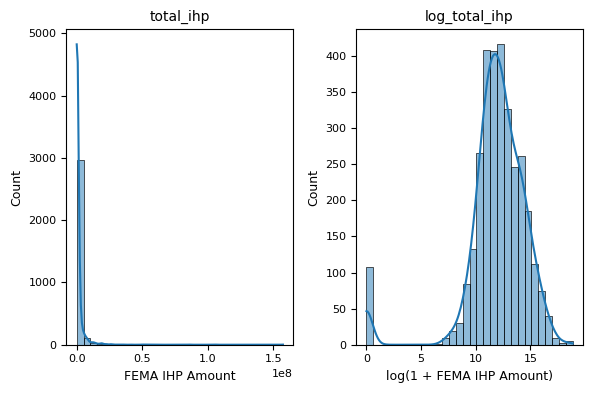

In [16]:
#| label: fig-fema-y-dist
#| fig-cap: "Distribution of county-level FEMA Individuals and Households Program (IHP) disaster assistance totals across 3,144 U.S. counties. The raw target is highly right-skewed, with many counties receiving no recorded assistance and a small number receiving very large amounts. The log-transformed target, log(1 + total_ihp), reduces skewness and provides a more stable scale for regression modeling."

plot_df = y.copy()
plot_df["log_total_ihp"] = np.log1p(plot_df["total_ihp"])

fig, axes = plt.subplots(1, 2, figsize=(6, 4))

sns.histplot(
    plot_df["total_ihp"],
    bins=30,
    kde=True,
    ax=axes[0]
)
axes[0].set_title("total_ihp")
axes[0].set_xlabel("FEMA IHP Amount")
axes[0].set_ylabel("Count")

sns.histplot(
    plot_df["log_total_ihp"],
    bins=30,
    kde=True,
    ax=axes[1]
)
axes[1].set_title("log_total_ihp")
axes[1].set_xlabel("log(1 + FEMA IHP Amount)")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [17]:
#| output: false

# Create log-transformed target for modeling
y_log = y.copy()
y_log["log_total_ihp"] = np.log1p(y_log["total_ihp"])

# Keep only the transformed target
y_log = y_log[["log_total_ihp"]]

display(y_log.head())

,log_total_ihp
0,13.432184
1,17.044533
2,12.850146
3,11.243348
4,12.164800


### Geographic Distribution of Disaster Assistance

Spatial patterns in county-level FEMA disaster assistance are shown in @fig-fema-y-map-conus for the contiguous United States and in @fig-fema-y-map-oconus for Alaska and Hawaii. The maps indicate substantial geographic variation in disaster assistance across counties, with clear clustering in several regions. Higher levels of assistance appear across parts of the Gulf Coast, the Southeast, portions of the Atlantic seaboard, and selected areas in the West, while many interior counties show comparatively lower values. These patterns are consistent with the uneven spatial distribution of disaster impacts and recovery funding over the 2018–2020 period.

The maps also suggest that disaster assistance is spatially clustered rather than randomly distributed. Neighboring counties often exhibit similar levels of assistance, reflecting the fact that disaster events frequently affect broader regional areas rather than isolated counties. This pattern supports the use of spatially informed models that can account for geographic dependence across counties.

The Alaska and Hawaii maps in @fig-fema-y-map-oconus show additional geographic heterogeneity outside the contiguous United States. Alaska exhibits substantial variation across boroughs and census areas, while Hawaii shows generally elevated assistance levels across several islands. Together, these patterns suggest that spatial context may provide useful information for modeling county-level disaster assistance outcomes.

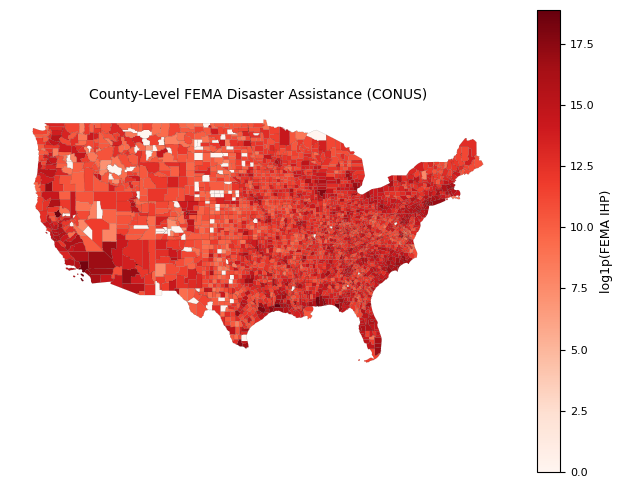

In [18]:
#| label: fig-fema-y-map-conus
#| fig-cap: "County-level distribution of FEMA Individuals and Households Program (IHP) disaster assistance across the contiguous United States (CONUS) from 2018–2020. Darker shades indicate higher levels of assistance (log1p(FEMA IHP)). Spatial clustering across neighboring counties suggests that geographic structure may contain useful information for predictive modeling, motivating the use of graph-based approaches."

fig, ax = plt.subplots(1, 1, figsize=(8, 6))

# Remove Alaska, Hawaii, and territories
conus = geo_df[~geo_df["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))].copy()

conus["log_total_ihp"] = np.log1p(conus["total_ihp"])

conus.plot(
    column="log_total_ihp",
    cmap="Reds",
    linewidth=0.05,
    edgecolor="black",
    legend=True,
    legend_kwds={"label": "log1p(FEMA IHP)"},
    ax=ax
)

ax.set_title("County-Level FEMA Disaster Assistance (CONUS)")
ax.axis("off")

plt.show()

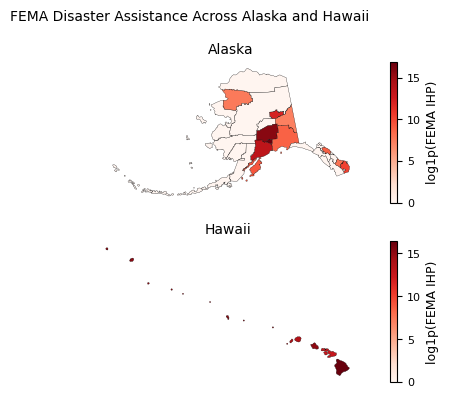

In [19]:
#| label: fig-fema-y-map-oconus
#| fig-cap: "County-level FEMA Individuals and Households Program (IHP) disaster assistance for Alaska and Hawaii from 2018–2020. Darker shades indicate higher levels of assistance measured as log1p(FEMA IHP)."

# Define Alaska and Hawaii only
ak = geo_df[geo_df["FIPS"].str.startswith("02")].copy()
hi = geo_df[geo_df["FIPS"].str.startswith("15")].copy()

ak["log_total_ihp"] = np.log1p(ak["total_ihp"])
hi["log_total_ihp"] = np.log1p(hi["total_ihp"])

# Convert to specific CRS for reprojection
ak_proj = ak.to_crs("EPSG:3338")
hi_proj = hi.to_crs("EPSG:3759")

fig, axes = plt.subplots(2, 1, figsize=(6, 4))

fig.suptitle(
    "FEMA Disaster Assistance Across Alaska and Hawaii",
    fontsize=10
)

oconus_datasets = [
    (ak_proj, "Alaska"),
    (hi_proj, "Hawaii")
]

for ax, (data, title) in zip(axes, oconus_datasets):
    if data.empty:
        ax.text(0.5, 0.5, f"No data for {title}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    data.plot(
        column="log_total_ihp",
        cmap="Reds",
        linewidth=0.2,
        edgecolor="black",
        legend=True,
        legend_kwds={"label": "log1p(FEMA IHP)"},
        ax=ax
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

## Feature Matrix

The predictor variables used in this study are the **15 SVI percentage indicators (`EP_*`)**, which represent estimated proportions of populations experiencing conditions associated with social vulnerability. These indicators capture multiple dimensions of vulnerability including socioeconomic status, household characteristics, minority status and language barriers, and housing and transportation conditions. Because the variables are expressed primarily as population percentages rather than raw counts, they allow counties with different population sizes to be compared on a consistent scale.

To understand the statistical structure of the feature space and guide preprocessing decisions, several analyses are conducted, including distribution analysis, moment diagnostics, transformation evaluation, correlation & multicollinearity assessment, and unsupervised clustering with PCA.

In [20]:
# Short titles based on CDC SVI documentation
feature_titles = {
    # Theme 1: Socioeconomic Status
    "EP_POV": "Below Poverty (%)",
    "EP_UNEMP": "Unemployment (%)",
    "EP_PCI": "Per Capita Income",
    "EP_NOHSDP": "No High School Diploma (%)",

    # Theme 2: Household Characteristics
    "EP_AGE65": "Age 65+ (%)",
    "EP_AGE17": "Age ≤17 (%)",
    "EP_DISABL": "Disability (%)",
    "EP_SNGPNT": "Single-Parent HH (%)",

    # Theme 3: Minority Status and Language
    "EP_MINRTY": "Minority (%)",
    "EP_LIMENG": "Limited English (%)",

    # Theme 4: Housing Type and Transportation
    "EP_MUNIT": "Multi-Unit Housing (%)",
    "EP_MOBILE": "Mobile Homes (%)",
    "EP_CROWD": "Crowded Housing (%)",
    "EP_NOVEH": "No Vehicle (%)",
    "EP_GROUPQ": "Group Quarters (%)"
}

# Define cols and n for plotting
cols = X.columns
n_cols = len(cols)

### Feature Distributions

The distributions of the SVI indicator variables across counties are shown in @fig-svi-x-dist. Several indicators display strong right-skew, where most counties have relatively low values while a smaller subset exhibits substantially higher levels. This pattern is particularly evident for variables related to housing and language barriers, such as crowded housing, group quarters, multi-unit housing, and limited English proficiency.

During validation of the feature distributions, one county (FIPS 35039: Rio Arriba County, New Mexico) was found to contain sentinel values of `-999` for the unemployment and poverty indicators. As shown in @tbl-svi-sentinel-check, these values represent missing or suppressed ACS estimates rather than valid observations. To avoid distorting summary statistics, visualizations, and downstream model inputs, this county is removed from the analytic dataset prior to modeling.

Other variables, including age structure and disability rates, appear more symmetric and concentrated around typical population ranges. Per capita income shows moderate skewness, reflecting variation in economic conditions across counties. Overall, the feature distributions indicate that vulnerability conditions are unevenly distributed across counties. These patterns suggest that some predictors may benefit from scaling or transformation to improve numerical behavior during model training.

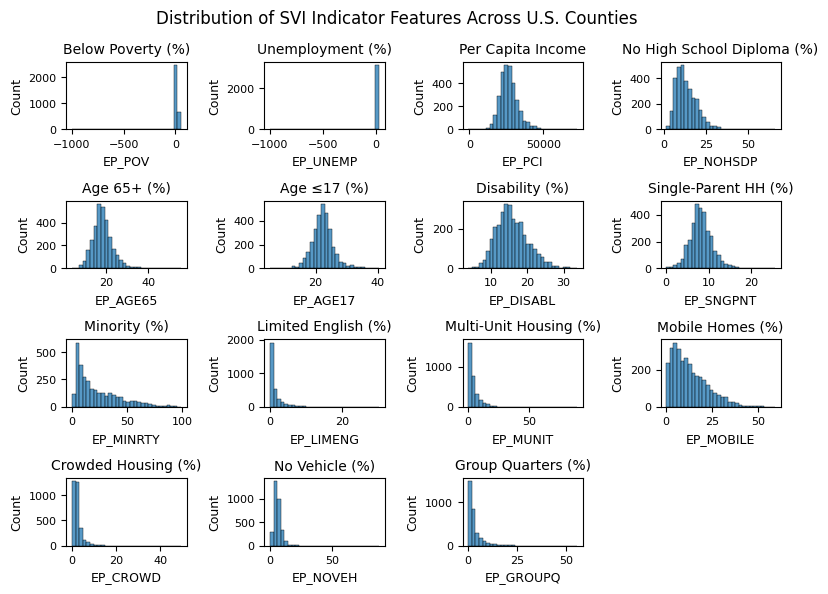

In [21]:
#| label: fig-svi-x-dist
#| fig-cap: "Empirical distributions of county-level SVI indicator variables used as model input features. Each subplot shows the frequency distribution of a socioeconomic, demographic, or housing indicator across U.S. counties. Several variables exhibit pronounced right-skew and heavy tails, particularly housing and language-related indicators, motivating subsequent distribution diagnostics and selective log transformation."

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Distribution of SVI Indicator Features Across U.S. Counties",
    fontsize=12
)

for i, col in enumerate(cols):
    sns.histplot(X[col], bins=30, ax=axes[i])

    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].set_title(feature_titles.get(col, col))

for j in range(n_cols, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [22]:
#| label: tbl-svi-sentinel-check
#| tbl-cap: "Summary statistics for unemployment and poverty indicators prior to data cleaning. The minimum value of −999 indicates sentinel values used in the SVI dataset to represent missing or suppressed ACS estimates. The table also reports the number of sentinel values observed for each variable and the county FIPS where the sentinel value occurs."

missing_df = model_df[["EP_UNEMP", "EP_POV"]].describe().T
missing_df["sent_count"] = (model_df[["EP_UNEMP", "EP_POV"]] == -999).sum()

sentinel_fips = model_df.loc[
    (model_df[["EP_UNEMP", "EP_POV"]] == -999).any(axis=1),
    "FIPS"
].iloc[0]

missing_df["sent_fips"] = sentinel_fips

display(missing_df)

,count,mean,std,min,25%,50%,75%,max,sent_count,sent_fips
EP_UNEMP,3142.0,5.453851,18.150447,-999.0,4.0,5.4,7.1,28.9,1,35039
EP_POV,3142.0,15.278294,19.224674,-999.0,11.0,14.7,19.1,55.1,1,35039


In [23]:
# Replace -999 with nan & drop
geo_df[feature_cols_ep] = geo_df[feature_cols_ep].replace(-999, np.nan)
geo_df = geo_df.dropna(subset=feature_cols_ep)

# Rebuild 
model_df = geo_df[["FIPS"] + feature_cols_ep + target].copy()
X = model_df[feature_cols_ep].copy()
y = model_df[target].copy()
y_log = np.log1p(y).copy()

### Distribution Moments and Skewness

Skewness and kurtosis statistics for the SVI indicators are shown in @fig-svi-moments. Several variables exhibit substantial positive skewness, indicating that most counties report relatively low values while a smaller subset exhibits much higher concentrations. This pattern is particularly pronounced for housing and transportation indicators such as no vehicle access, crowded housing, and multi-unit housing, which also display very high kurtosis values, reflecting heavy-tailed distributions.

Other indicators, including age structure, disability, and minority population share, appear more symmetric with comparatively low skewness and kurtosis. Per capita income shows moderate right-skew, indicating the presence of higher-income outliers among a smaller number of counties.

These distributional patterns are typical for socioeconomic indicators, where vulnerability conditions tend to be concentrated within particular regions or demographic groups rather than evenly distributed across counties. The presence of skewness and heavy tails suggests that scaling or transformation may help stabilize variance and improve numerical behavior during model training.

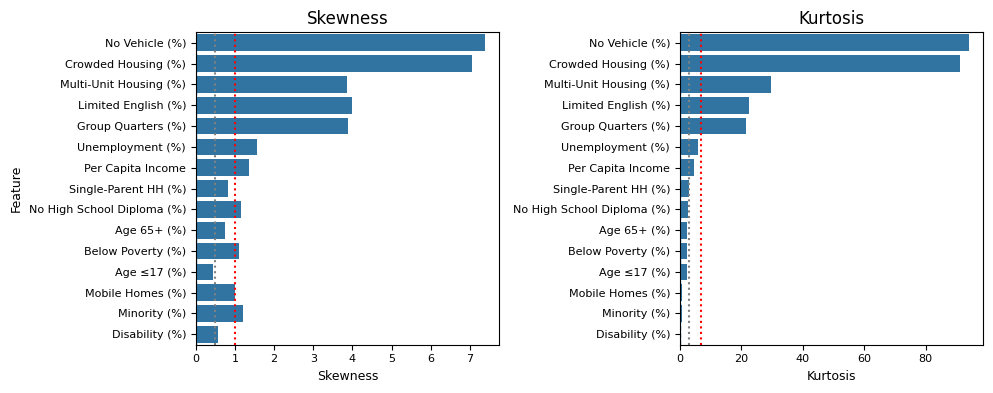

In [24]:
#| label: fig-svi-moments
#| fig-cap: "Skewness and kurtosis diagnostics for county-level SVI indicator variables. The left panel shows skewness (distribution asymmetry) and the right panel shows kurtosis (tail heaviness relative to a normal distribution). Vertical reference lines indicate commonly used thresholds for moderate and strong deviations from normality, highlighting substantial right-skew and heavy tails in several housing and demographic indicators."

# Compute distribution statistics
moments = pd.DataFrame({
    "Variable": X.columns,
    "Skewness": X.skew(),
    "Kurtosis": X.kurtosis()
})

# Map readable feature names
moments["Feature"] = moments["Variable"].map(feature_titles).fillna(moments["Variable"])

# Sort by kurtosis
moments = moments.sort_values("Kurtosis", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Skewness
sns.barplot(
    x="Skewness",
    y="Feature",
    data=moments,
    ax=axes[0],
    orient="h"
)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(0.5, linestyle=":", color="gray")
axes[0].axvline(1, linestyle=":", color="red")

axes[0].set_title("Skewness", fontsize=12)
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Feature")

# Kurtosis
sns.barplot(
    x="Kurtosis",
    y="Feature",
    data=moments,
    ax=axes[1],
    orient="h"
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(3, linestyle=":", color="gray")
axes[1].axvline(7, linestyle=":", color="red")

axes[1].set_title("Kurtosis", fontsize=12)
axes[1].set_xlabel("Kurtosis")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Log Transformation Effects

To reduce skewness and heavy-tailed behavior, selected variables are transformed using `log1p`. The effects of these transformations are summarized in @fig-svi-log-moments and illustrated in @fig-svi-x-log-dist.

The following variables were log-transformed due to strong right-skew and heavy-tailed distributions:

- Crowded Housing (%) — `EP_CROWD`
- Limited English (%) — `EP_LIMENG`
- Group Quarters (%) — `EP_GROUPQ`
- Multi-Unit Housing (%) — `EP_MUNIT`
- No Vehicle (%) — `EP_NOVEH`

After transformation, these features exhibit reduced skewness and kurtosis, resulting in more symmetric distributions. Most transformed variables now fall closer to moderate skewness ranges, indicating improved distributional balance. Other variables—including age structure, disability, minority population share, and socioeconomic indicators—retain approximately symmetric distributions and therefore remain untransformed. Overall, the selective log transformation reduces the influence of extreme values while preserving the interpretability of the underlying vulnerability indicators, improving numerical stability during model training.

In [25]:
# Variables to log-transform based on skewness diagnostics
log_vars = [
    "EP_NOVEH",
    "EP_CROWD",
    "EP_MUNIT",
    "EP_LIMENG",
    "EP_GROUPQ"
]

# Copy original feature matrix (do not change row indices beyond this)
X_log = X.copy()

# Create log-transformed columns
for col in log_vars:
    X_log[f"{col}_LOG"] = np.log1p(X_log[col])

# Drop original versions
X_log = X_log.drop(columns=log_vars)

# Reorder columns for readability
X_log = X_log.reindex(sorted(X_log.columns), axis=1)

# Update feature title mapping
feature_titles_log = feature_titles.copy()
feature_titles_log.update({
    "EP_NOVEH_LOG": "No Vehicle (log)",
    "EP_CROWD_LOG": "Crowded Housing (log)",
    "EP_MUNIT_LOG": "Multi-Unit Housing (log)",
    "EP_LIMENG_LOG": "Limited English (log)",
    "EP_GROUPQ_LOG": "Group Quarters (log)"
})

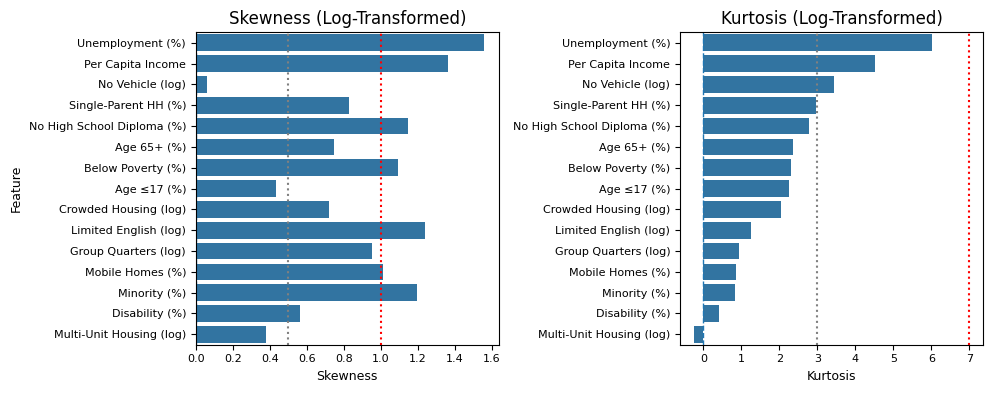

In [26]:
#| label: fig-svi-log-moments
#| fig-cap: "Skewness and kurtosis diagnostics for SVI indicators after selective log transformation using log(x+1). The transformation reduces strong right-skew and heavy-tailed behavior observed in several housing and language indicators. Vertical reference lines indicate common interpretation thresholds for skewness (|0.5| moderate, |1| strong) and kurtosis (3 moderate, 7 heavy-tailed), helping assess the extent to which the transformed variables approach more symmetric distributions."

moments_log = pd.DataFrame({
    "Variable": X_log.columns,
    "Skewness": X_log.skew(),
    "Kurtosis": X_log.kurtosis()
})

moments_log["Feature"] = moments_log["Variable"].map(feature_titles_log).fillna(moments_log["Variable"])

moments_log = moments_log.sort_values("Kurtosis", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Skewness
sns.barplot(
    x="Skewness",
    y="Feature",
    data=moments_log,
    ax=axes[0],
    orient="h"
)

axes[0].axvline(0, linestyle="--", linewidth=1)
axes[0].axvline(0.5, linestyle=":", color="gray")
axes[0].axvline(1, linestyle=":", color="red")

axes[0].set_title("Skewness (Log-Transformed)", fontsize=12)
axes[0].set_xlabel("Skewness")
axes[0].set_ylabel("Feature")

# Kurtosis
sns.barplot(
    x="Kurtosis",
    y="Feature",
    data=moments_log,
    ax=axes[1],
    orient="h"
)

axes[1].axvline(0, linestyle="--", linewidth=1)
axes[1].axvline(3, linestyle=":", color="gray")
axes[1].axvline(7, linestyle=":", color="red")

axes[1].set_title("Kurtosis (Log-Transformed)", fontsize=12)
axes[1].set_xlabel("Kurtosis")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

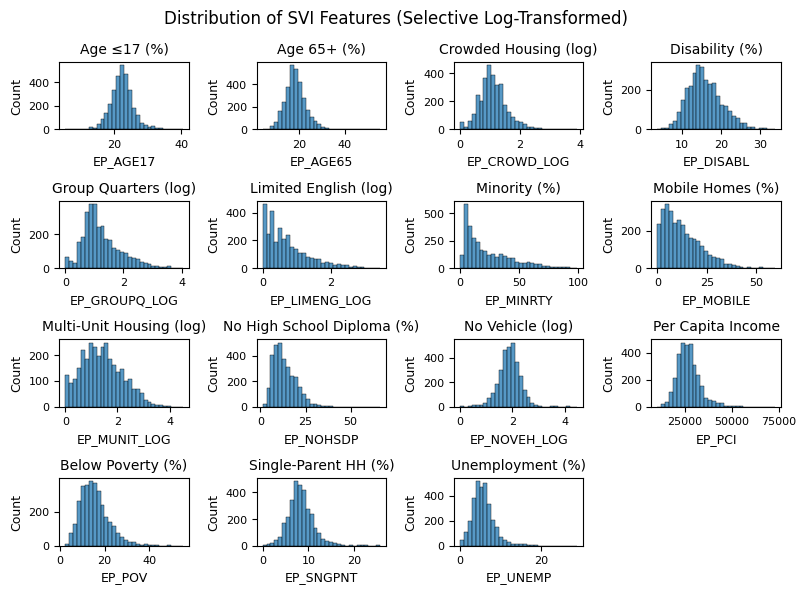

In [27]:
#| label: fig-svi-x-log-dist
#| fig-cap: "Distributions of the final SVI feature set after selective log transformation. Variables exhibiting strong right-skew were transformed using log(x+1), improving symmetry and reducing heavy-tailed behavior."

cols_log = X_log.columns
n_cols_log = len(cols_log)

fig, axes = plt.subplots(4, 4, figsize=(8, 6))
axes = axes.flatten()

fig.suptitle(
    "Distribution of SVI Features (Selective Log-Transformed)",
    fontsize=12
)

for i, col in enumerate(cols_log):
    sns.histplot(X_log[col], bins=30, ax=axes[i])

    axes[i].set_title(feature_titles_log.get(col,col))
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

for j in range(n_cols_log, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

### Feature Correlation Structure

The correlation matrix in @fig-svi-corr shows relationships among the transformed SVI indicators. Several moderate correlations appear across socioeconomic variables. For example, poverty, unemployment, and lack of a high school diploma are positively correlated, reflecting the close relationship between education, labor market conditions, and economic hardship. Single-parent households and minority population share also show moderate positive associations with these indicators.

Housing and transportation variables exhibit additional structure. Crowded housing and limited English proficiency are moderately correlated with minority population share, while multi-unit housing is negatively correlated with mobile homes, reflecting different housing patterns across urban and rural counties. Per capita income shows negative correlations with several vulnerability indicators, particularly poverty and unemployment.

Although some relationships are moderately strong, most correlations remain **below levels typically associated with severe multicollinearity**. This suggests that the predictors capture related but distinct aspects of social vulnerability, providing complementary information for the regression and graph-based models used in the study.

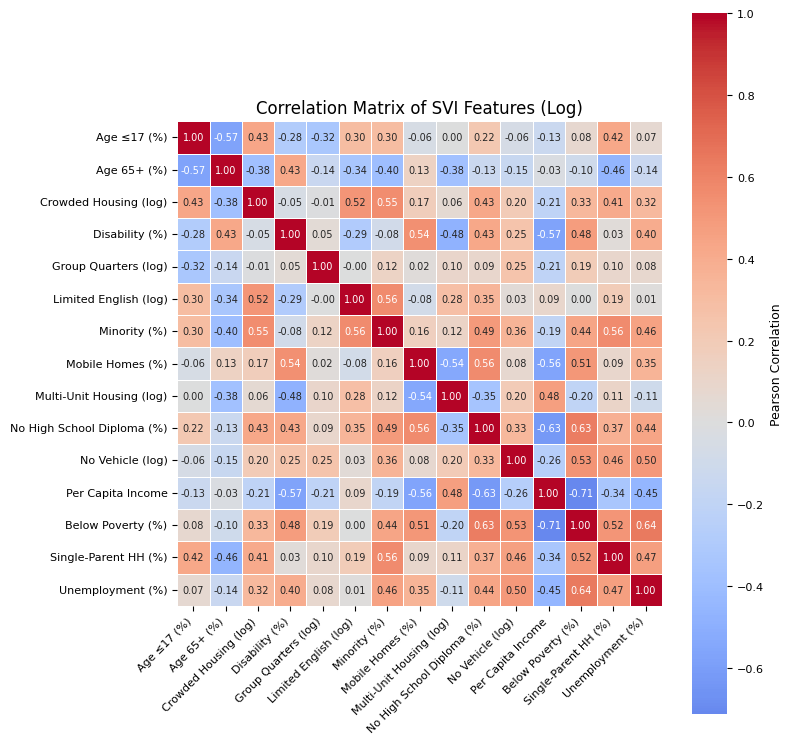

In [28]:
#| label: fig-svi-corr
#| fig-cap: "Pearson correlation matrix of the Social Vulnerability Index (SVI) feature set after selective log transformation. Several socioeconomic indicators—including poverty, unemployment, and lack of high school education—exhibit moderate to strong positive correlations, reflecting shared underlying economic vulnerability. Housing-related indicators such as crowding, multi-unit housing, and limited English proficiency also show notable associations with minority population measures. In contrast, age-based indicators (population under 17 and over 65) display weaker relationships with most socioeconomic variables, indicating distinct demographic patterns across counties."

# Compute correlation matrix
corr = X_log[cols_log].corr()

# Rename for readability in the heatmap
corr_plot = corr.rename(index=feature_titles_log, columns=feature_titles_log)

plt.figure(figsize=(8, 8))

sns.heatmap(
    corr_plot,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    annot=True,        
    fmt=".2f",          
    annot_kws={"size":7},
    cbar_kws={"label": "Pearson Correlation"}
)

plt.title("Correlation Matrix of SVI Features (Log)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Multicollinearity Assessment

To evaluate redundancy among predictors, variance inflation factors (VIF) are computed for both the original and selectively log-transformed feature sets. The distribution of VIF values across threshold categories is summarized in @tbl-svi-vif-thresholds, while detailed feature-level statistics are reported in @tbl-svi-vif.

Several variables exhibit elevated VIF values, indicating moderate to high multicollinearity among certain vulnerability indicators. In particular, demographic variables such as age ≤17, disability, and age ≥65 show relatively high VIF values, reflecting strong associations among age structure, household composition, and socioeconomic conditions. Poverty, single-parent households, and educational attainment also demonstrate notable collinearity, which is consistent with well-established relationships between education, income, and household structure.

Applying selective log transformations to highly skewed housing and transportation indicators modestly reduces multicollinearity for some features. However, the overall correlation structure remains similar because many SVI indicators measure closely related aspects of social and economic vulnerability. These results suggest that while some redundancy exists among predictors, the feature set still captures multiple complementary dimensions of vulnerability suitable for predictive modeling.

In [29]:
#| label: tbl-svi-vif
#| tbl-cap: "Variance Inflation Factor (VIF) for SVI indicator variables before and after selective log transformation. Variables in the original feature set (X) and transformed feature set (X_log) are sorted independently in descending order of VIF. The results show that multicollinearity remains substantial across several socioeconomic and housing-related indicators, and in some cases increases after log transformation, reflecting the strong structural relationships inherent in the SVI variables."

# VIF for original features
vif_X = pd.DataFrame({
    "X_feature": X.columns,
    "VIF_X": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
}).sort_values("VIF_X", ascending=False).reset_index(drop=True)

# VIF for log-transformed features
vif_X_log = pd.DataFrame({
    "X_log_feature": X_log.columns,
    "VIF_X_log": [variance_inflation_factor(X_log.values, i) for i in range(X_log.shape[1])]
}).sort_values("VIF_X_log", ascending=False).reset_index(drop=True)

# Combine side-by-side
vif_table = pd.concat([vif_X, vif_X_log], axis=1)

# Display without index
display(vif_table.style.hide(axis="index"))

X_feature,VIF_X,X_log_feature,VIF_X_log
EP_AGE17,48.313311,EP_AGE17,44.732245
EP_PCI,39.124983,EP_NOVEH_LOG,40.365640
EP_DISABL,38.579696,EP_DISABL,38.370078
EP_AGE65,30.346199,EP_PCI,37.213443
EP_POV,24.721876,EP_AGE65,28.647693
EP_SNGPNT,22.643122,EP_POV,25.427935
EP_NOHSDP,22.140232,EP_SNGPNT,23.696164
EP_UNEMP,11.386736,EP_NOHSDP,19.594090
EP_MINRTY,6.596296,EP_CROWD_LOG,12.474906
EP_MOBILE,6.150925,EP_UNEMP,11.213729


In [30]:
#| label: tbl-svi-vif-thresholds
#| tbl-cap: "Counts and rates of SVI indicator variables falling within common VIF threshold ranges before and after selective log transformation, indicating that multicollinearity remains substantial and increases overall after transformation."

threshold_table = pd.DataFrame({
    "Threshold": [
        "VIF < 5 (Low)",
        "5 ≤ VIF < 10 (Moderate)",
        "VIF ≥ 10 (High)"
    ],
    "Count_X": [
        (vif_X["VIF_X"] < 5).sum(),
        ((vif_X["VIF_X"] >= 5) & (vif_X["VIF_X"] < 10)).sum(),
        (vif_X["VIF_X"] >= 10).sum()
    ],
    "Rate_X": [
        round((vif_X["VIF_X"] < 5).sum() / len(vif_X), 2),
        round(((vif_X["VIF_X"] >= 5) & (vif_X["VIF_X"] < 10)).sum() / len(vif_X), 2),
        round((vif_X["VIF_X"] >= 10).sum() / len(vif_X), 2)
    ],
    "Count_X_log": [
        (vif_X_log["VIF_X_log"] < 5).sum(),
        ((vif_X_log["VIF_X_log"] >= 5) & (vif_X_log["VIF_X_log"] < 10)).sum(),
        (vif_X_log["VIF_X_log"] >= 10).sum()
    ],
    "Rate_X_log": [
        round((vif_X_log["VIF_X_log"] < 5).sum() / len(vif_X_log), 2),
        round(((vif_X_log["VIF_X_log"] >= 5) & (vif_X_log["VIF_X_log"] < 10)).sum() / len(vif_X_log), 2),
        round((vif_X_log["VIF_X_log"] >= 10).sum() / len(vif_X_log), 2)
    ]
})

# Format rate columns to two decimals
threshold_table["Rate_X"] = threshold_table["Rate_X"].map("{:.2f}".format)
threshold_table["Rate_X_log"] = threshold_table["Rate_X_log"].map("{:.2f}".format)

display(threshold_table.style.hide(axis="index"))

Threshold,Count_X,Rate_X,Count_X_log,Rate_X_log
VIF < 5 (Low),4,0.27,0,0.00
5 ≤ VIF < 10 (Moderate),3,0.20,4,0.27
VIF ≥ 10 (High),8,0.53,11,0.73


### Cluster Analysis, PCA, and Latent Structure

To further understand the structure of the EP_* feature space, unsupervised clustering and dimensionality reduction are performed. These analyses help identify whether counties naturally group into similar vulnerability profiles and whether the high-dimensional feature matrix can be represented in a smaller number of latent components.

#### K-Means Cluster Diagnostics

To determine an appropriate number of clusters, K-means clustering is evaluated across multiple values of (k). The results are summarized numerically in @tbl-svi-kmeans-diagnostics and visually in @fig-svi-kmeans-diagnostics.

The inertia curve decreases monotonically as (k) increases, which is expected since additional clusters reduce within-cluster variance. However, the **largest reductions occur between (k=1) and (k=4)**, after which improvements become progressively smaller. The silhouette scores show their highest value at (k=2), indicating the strongest separation between two broad vulnerability regimes, but scores gradually decline as additional clusters are introduced.

The gap statistic and Calinski–Harabasz index suggest diminishing returns beyond approximately (k=4). Taken together, these diagnostics indicate that a **four-cluster solution provides a reasonable balance between cluster separation and interpretability**, capturing meaningful variation without excessive fragmentation.

In [31]:
#| label: tbl-svi-kmeans-diagnostics
#| tbl-cap: "K-means clustering diagnostics across candidate numbers of clusters (k = 1–10) computed using standardized log-transformed SVI indicators. The table reports inertia (within-cluster dispersion), silhouette score, Calinski–Harabasz index, and the gap statistic with its standard error (sk). Together these metrics help identify an appropriate number of clusters by evaluating cluster compactness, separation, and improvement relative to a reference distribution."

# Standardize before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_log)

# Set range for K
k_range = range(1, 11)

# Evaluate Kmeans metrics
metrics_df = evaluate_kmeans_k(
    X_scaled,
    k_range=k_range,
    random_state=42,
    n_init=20,
    n_refs_gap=20,
)

display(metrics_df.style.hide(axis="index"))

k,inertia,silhouette,calinski_harabasz,gap,sk
1,47115.000000,nan,nan,1.778737,0.004076
2,37360.302293,0.212492,819.590566,1.916863,0.006812
3,33054.221370,0.184039,667.433060,1.986000,0.005544
4,30113.653350,0.145460,590.358291,2.038525,0.003342
5,28390.766457,0.137476,517.062444,2.063242,0.004125
6,26755.673731,0.126731,477.106191,2.093067,0.004476
7,25506.535710,0.130298,442.507023,2.115191,0.004855
8,24481.875031,0.123960,413.773049,2.134982,0.005463
9,23636.681567,0.118487,388.877707,2.148284,0.005271
10,22875.919712,0.117847,368.619352,2.164516,0.004710


In [32]:
#| output: false

# Check for a recommended K by gap rule
k_gap = choose_k_gap_rule(metrics_df[["k", "gap", "sk"]])
print("Gap-statistic recommended k:", k_gap)

Gap-statistic recommended k: None


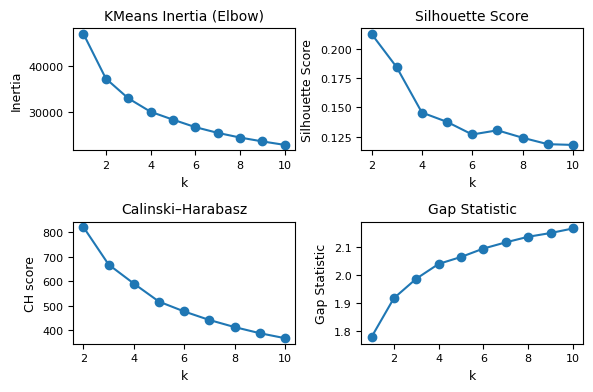

In [33]:
#| label: fig-svi-kmeans-diagnostics
#| fig-cap: "Clustering diagnostics for K-means across candidate numbers of clusters (k = 1–10) using standardized log-transformed SVI indicators. The elbow curve (inertia) measures within-cluster dispersion, the silhouette score evaluates cluster separation, the Calinski–Harabasz index assesses cluster compactness relative to between-cluster variance, and the gap statistic compares observed clustering structure to a reference null distribution. Together these metrics suggest diminishing returns beyond approximately k ≈ 3–4 clusters."

# Plot Kmean metrics
plot_k_diagnostics(metrics_df)

#### Cluster Visualization in PCA Space

To visualize the cluster structure, counties are projected into the first two principal components and colored according to cluster assignment. The resulting visualization is shown in @fig-svi-kmeans-pca-clusters. The first two principal components explain approximately **32.2% and 21.9% of the variance**, respectively, capturing over half of the total variation in the feature space. This projection provides a useful low-dimensional representation of the county-level vulnerability profiles.

The clusters form partially overlapping but distinguishable regions within this space. Some groups appear more compact while others are more dispersed, suggesting variation in how strongly counties align with particular vulnerability profiles. The overlap between clusters reflects the continuous nature of socioeconomic vulnerability, where counties often share characteristics across multiple vulnerability dimensions rather than forming sharply separated groups.

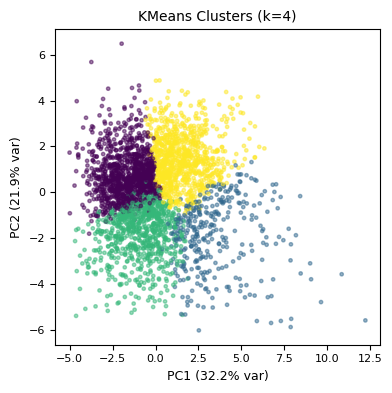

In [34]:
#| label: fig-svi-kmeans-pca-clusters
#| fig-cap: "Two-dimensional PCA projection of counties based on standardized log-transformed SVI indicators, colored by K-means cluster assignment (k = 4). Each point represents a county, while the axes correspond to the first two principal components explaining 29.3% and 20.5% of the total variance, respectively. The separation of colored groups indicates that the clusters capture meaningful structure in the multidimensional vulnerability feature space."

# Pick a K and fit
k_final = 4
km, labels = fit_kmeans(X_scaled, k=k_final, random_state=42, n_init=20)

# Project PCs
Z2, evr = pca_project(X_scaled, n_components=2)
plot_clusters_pca(Z2, labels, evr, title=f"KMeans Clusters (k={k_final})")

#### Cluster Feature Profiles

The mean feature values for each cluster are summarized in @tbl-svi-cluster-profiles and visualized as standardized feature profiles in @fig-svi-cluster-heatmap. These profiles illustrate how counties group into distinct combinations of vulnerability indicators.

**Cluster 0** is characterized by relatively high per capita income (EP_PCI) and comparatively low values across many vulnerability indicators, including minority population share, unemployment, and single-parent households. This cluster broadly represents counties with lower overall socioeconomic vulnerability.

**Cluster 1** exhibits elevated socioeconomic stress indicators. It shows high poverty (EP_POV), unemployment (EP_UNEMP), limited English proficiency (EP_LIMENG), minority population share (EP_MINRTY), and lower per capita income (EP_PCI). This profile reflects counties experiencing multiple overlapping socioeconomic and demographic vulnerabilities.

**Cluster 2** shows moderate vulnerability across many indicators, with somewhat higher housing-related characteristics such as multi-unit housing and group quarters. These counties appear to represent transitional profiles with mixed socioeconomic and demographic characteristics.

**Cluster 3** is associated with relatively high housing and demographic pressures, including higher crowded housing (EP_CROWD), mobile homes (EP_MOBILE), and elevated poverty and unemployment levels compared with Cluster 0. Per capita income in this cluster is lower than in the lowest-vulnerability cluster, reinforcing the connection between economic conditions and vulnerability outcomes.

Per capita income (EP_PCI) plays an important role in differentiating clusters. Counties with higher income levels tend to align with clusters exhibiting lower poverty and unemployment, while clusters with lower income correspond to elevated socioeconomic stress indicators. This inverse relationship is consistent with the negative correlations observed earlier between EP_PCI and several vulnerability measures.

Overall, the cluster profiles highlight the multidimensional nature of vulnerability, where counties exhibit different combinations of socioeconomic, demographic, and housing-related risk factors rather than a single dominant driver.

In [35]:
#| label: tbl-svi-cluster-profiles
#| tbl-cap: "Mean values of log-transformed SVI indicator variables for each K-means cluster (k = 4). Columns represent cluster centroids in feature space, while the spread column reports the difference between the maximum and minimum cluster mean for each indicator, highlighting the variables that most strongly differentiate vulnerability profiles across clusters."

cluster_profile = (
    pd.DataFrame(X_log, columns=X_log.columns)
    .assign(cluster=labels)
    .groupby("cluster")
    .mean()
)
cluster_table = cluster_profile.T
cluster_table["spread"] = cluster_table.max(axis=1) - cluster_table.min(axis=1)

display(cluster_table.sort_values("spread", ascending=False))


cluster,0,1,2,3,spread
EP_PCI,28949.951949,21780.257485,32085.600746,22131.540000,10305.343261
EP_MINRTY,9.967090,58.490120,26.552985,24.320778,48.523030
EP_MOBILE,9.578060,16.041018,6.003731,22.054556,16.050824
EP_NOHSDP,9.607616,22.367365,9.864303,17.903667,12.759750
EP_POV,11.819492,22.502994,12.653731,20.307667,10.683502
EP_DISABL,15.329193,14.979641,12.287935,20.243333,7.955398
EP_AGE65,21.340798,14.270659,14.825124,19.400778,7.070139
EP_AGE17,21.172801,26.856587,23.106841,21.488889,5.683785
EP_SNGPNT,6.705168,12.225749,8.555473,8.641444,5.520581
EP_UNEMP,4.159112,8.406587,5.090672,7.385333,4.247475


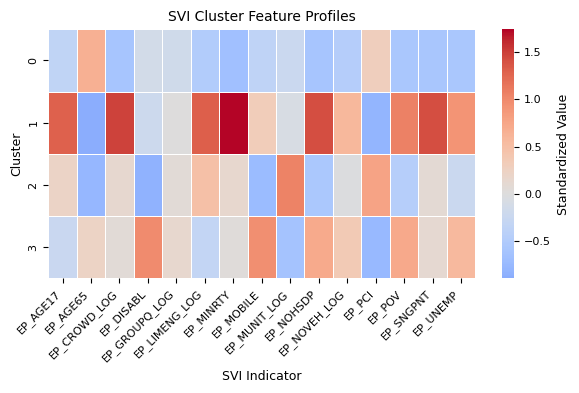

In [36]:
#| label: fig-svi-cluster-heatmap
#| fig-cap: "Heatmap of standardized cluster centroids for the K-means clustering solution (k = 4) based on log-transformed SVI indicators. Each row represents a cluster and each column corresponds to an SVI feature. Colors indicate the relative magnitude of each indicator compared to the overall mean after standardization, highlighting the vulnerability characteristics that distinguish the clusters."

cluster_profile_scaled = (
    pd.DataFrame(X_scaled, columns=X_log.columns)
    .assign(cluster=labels)
    .groupby("cluster")
    .mean()
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cluster_profile_scaled,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    cbar_kws={"label": "Standardized Value"}
)

plt.title("SVI Cluster Feature Profiles")
plt.xlabel("SVI Indicator")
plt.ylabel("Cluster")

plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

#### Geographic Distribution of Clusters

The spatial distribution of cluster assignments is shown for the contiguous United States (CONUS) in @fig-svi-cluster-map-conus and for Alaska and Hawaii (OCONUS) in @fig-svi-map-cluster-oconus.

Clear regional patterns emerge across the country. **Cluster 0**, associated with higher per capita income and lower socioeconomic vulnerability, appears frequently across portions of the Mountain West, Upper Midwest, and parts of the northern United States. In contrast, **Cluster 3**, which reflects higher poverty, unemployment, and single-parent household prevalence, is concentrated across many counties in the Southeast and parts of the Mississippi Delta.

**Cluster 1** appears prominently in several counties in the Southwest and portions of Alaska and is characterized by elevated minority population share, limited English proficiency, and lower income levels. **Cluster 2**, which reflects moderate vulnerability with mixed demographic and housing characteristics, is widely distributed across the Midwest and parts of the Great Plains.

The spatial coherence observed in these cluster patterns indicates that counties with similar vulnerability profiles tend to be geographically adjacent. This suggests that vulnerability is influenced not only by local socioeconomic conditions but also by broader regional structures and demographic patterns. The presence of clear geographic clustering supports the motivation for incorporating spatial relationships in subsequent modeling approaches, such as graph-based learning methods.

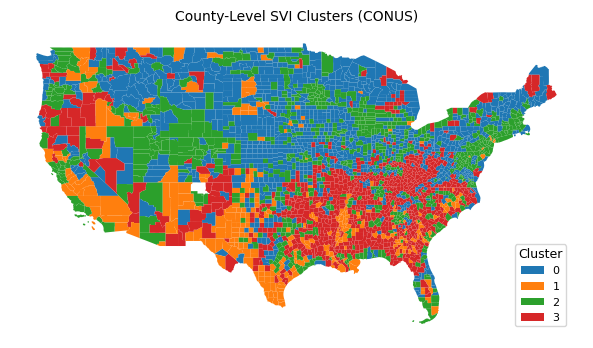

In [37]:
#| label: fig-svi-cluster-map-conus
#| fig-cap: "Geographic distribution of county-level vulnerability profiles across CONUS based on K-means clustering of standardized log-transformed SVI indicators. Each color represents a cluster of counties with similar socioeconomic, demographic, and housing characteristics. The spatial continuity of clusters suggests strong geographic structure in social vulnerability patterns."

geo_cluster = geo_df.copy()
geo_cluster["cluster"] = labels.astype(int)

# Remove Alaska, Hawaii, and territories
conus = geo_cluster[
    ~geo_cluster["FIPS"].str.startswith(("02", "15", "60", "66", "69", "72", "78"))
].copy()

# Match matplotlib default categorical colors
cluster_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
cluster_cmap = ListedColormap(cluster_colors)

fig, ax = plt.subplots(figsize=(6, 6))

conus.plot(
    column="cluster",
    cmap=cluster_cmap,
    categorical=True,
    linewidth=0.05,
    edgecolor="none",
    legend=False,   # turn off GeoPandas auto-legend
    ax=ax
)

# Manual legend so location is fully controllable
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor="none", label=str(i))
    for i in sorted(conus["cluster"].unique())
]

ax.legend(
    handles=handles,
    title="Cluster",
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    frameon=True,
    borderaxespad=0.5
)

ax.set_title("County-Level SVI Clusters (CONUS)")
ax.axis("off")

plt.tight_layout()
plt.show()

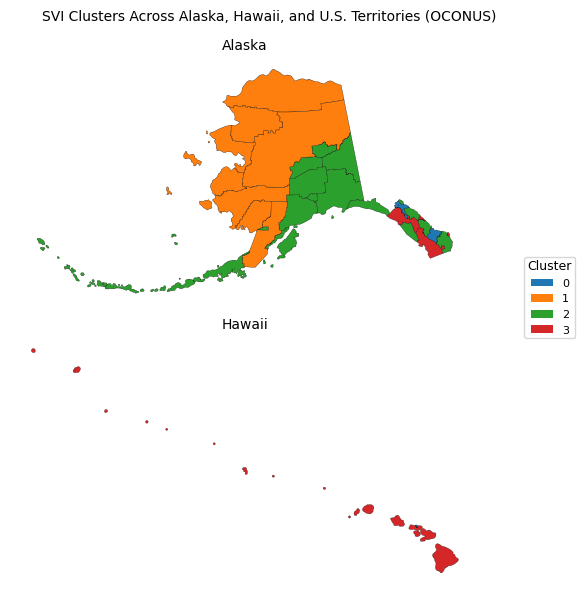

In [38]:
#| label: fig-svi-map-cluster-oconus
#| fig-cap: "County-level social vulnerability clusters for Alaska and Hawaii based on K-means clustering of standardized log-transformed SVI indicators. Colors represent distinct vulnerability profiles derived from the clustering analysis. Cluster assignments are shown for Alaska and Hawaii. No SVI feature data were available for the U.S. territories."

# Copy and attach cluster labels
geo_cluster = geo_df.copy()
geo_cluster["cluster"] = labels.astype(int)

# Define Alaska, Hawaii, and territories
ak = geo_cluster[geo_cluster["FIPS"].str.startswith("02")]
hi = geo_cluster[geo_cluster["FIPS"].str.startswith("15")]
territories = geo_cluster[geo_cluster["FIPS"].str.startswith(("60", "66", "69", "72", "78"))]

# Reproject for cleaner OCONUS display
ak_proj = ak.to_crs("EPSG:3338")
hi_proj = hi.to_crs("EPSG:3759")
territories_proj = territories.to_crs("EPSG:3857")

# Match map colors to cluster profile colors
cluster_colors = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
cluster_cmap = ListedColormap(cluster_colors)

fig, axes = plt.subplots(2, 1, figsize=(6, 6))

fig.suptitle(
    "SVI Clusters Across Alaska, Hawaii, and U.S. Territories (OCONUS)",
    fontsize=10
)

oconus_datasets = [
    (ak_proj, "Alaska"),
    (hi_proj, "Hawaii")
]

for ax, (data, title) in zip(axes, oconus_datasets):

    if data.empty:
        ax.text(0.5, 0.5, f"No data for {title}", ha="center", va="center")
        ax.set_title(title)
        ax.axis("off")
        continue

    data.plot(
        column="cluster",
        cmap=cluster_cmap,
        categorical=True,
        linewidth=0.2,
        edgecolor="black",
        legend=False,  # disable automatic legend
        ax=ax
    )

    ax.set_title(title)
    ax.axis("off")

# Create single manual legend
handles = [
    Patch(facecolor=cluster_colors[i], edgecolor="none", label=str(i))
    for i in sorted(geo_cluster["cluster"].unique())
]

fig.legend(
    handles=handles,
    title="Cluster",
    loc="center right",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True
)

plt.tight_layout(rect=[0, 0, 0.92, 1])
plt.show()

#### Principal Component Analysis

Principal Component Analysis (PCA) is applied to examine the intrinsic dimensionality of the EP_* feature matrix. The cumulative explained variance across principal components is shown in @fig-svi-pca-cumvar.

The first few principal components capture a substantial portion of the variance in the dataset. Approximately **80% of the variance is explained by around six to seven components**, while roughly **90% of the variance is captured by about nine components**. This indicates that although the dataset contains 15 original features, much of the variability in the vulnerability indicators can be summarized by a smaller number of latent dimensions. These latent components likely represent broader socioeconomic patterns that combine multiple related indicators, such as economic hardship, demographic dependency, or housing instability.

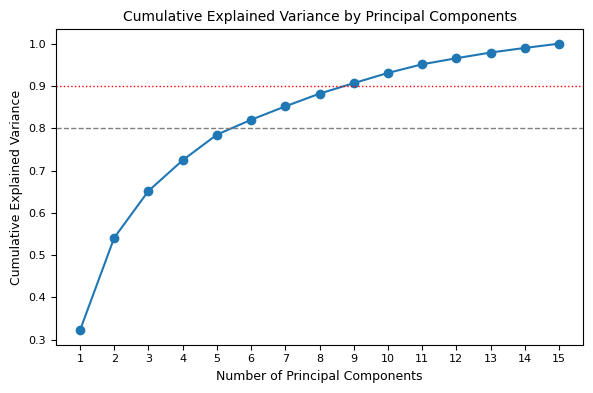

In [39]:
#| label: fig-svi-pca-cumvar
#| fig-cap: "Cumulative explained variance of principal components derived from standardized log-transformed SVI indicators. The first few components capture a substantial portion of total variance, with approximately 80% explained by the first six components and about 90% explained by the first nine components. Horizontal reference lines indicate common variance retention thresholds used to assess the dimensionality required to summarize county-level vulnerability patterns."

# Fit PCA on X_scaled
pca_full = PCA()
pca_full.fit(X_scaled)

# Compute explained variance
explained_var = pca_full.explained_variance_ratio_
cum_explained_var = explained_var.cumsum()
pcs = np.arange(1, len(explained_var) + 1)

plt.figure(figsize=(6, 4))
plt.plot(pcs, cum_explained_var, marker="o")
plt.axhline(0.80, linestyle="--", linewidth=1, color="gray")
plt.axhline(0.90, linestyle=":", linewidth=1, color="red")

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Explained Variance by Principal Components")
plt.xticks(pcs)

plt.tight_layout()
plt.show()

### Implications for Modeling

The exploratory analysis of the EP_* feature matrix reveals several characteristics relevant for model development. Several indicators exhibit right-skewed and heavy-tailed distributions. Selective `log1p` transformations are applied to certain variables to reduce skewness and stabilize variance while preserving the interpretability of the original indicators.

Correlation and VIF analyses indicate moderate to high multicollinearity among several socioeconomic variables, particularly those related to poverty, unemployment, educational attainment, and household composition. These relationships reflect the interconnected nature of socioeconomic vulnerability. Rather than removing correlated variables, the full feature set is retained because neural network models are generally robust to correlated inputs and can learn nonlinear relationships among predictors.

Principal component analysis and K-means clustering further reveal structured patterns within the feature space. The first two principal components capture a substantial portion of total variance, and clustering results suggest that counties can be grouped into a small number of broad vulnerability profiles. These clusters correspond to different combinations of economic, demographic, and housing-related conditions, with per capita income (EP_PCI) serving as a key differentiating factor across clusters.

Finally, the geographic distribution of cluster assignments shows clear spatial coherence, with neighboring counties often sharing similar vulnerability profiles. This spatial organization suggests that vulnerability is influenced by regional socioeconomic structures rather than isolated local conditions. Together, these findings support the modeling strategy adopted in this study: using the transformed EP_* indicators as predictors while allowing ML models—particularly graph-based approaches—to capture nonlinear feature interactions and spatial dependencies across counties.

In [40]:
# Save spatial dataset
geo_df.to_file(
    "../data/processed/svi_counties.gpkg",
    layer="counties",
    driver="GPKG"
)

# Save model matrices
X.to_csv("../data/processed/X.csv", index=False)
X_log.to_csv("../data/processed/X_log.csv", index=False)
y_log.to_csv("../data/processed/y_log.csv", index=False)

# Save county identifiers
geo_df[["FIPS"]].to_csv("../data/processed/fips.csv", index=False)

# Save feature titles as JSON
with open("../data/processed/feature_titles.json", "w") as f:
    json.dump(feature_titles_log, f, indent=2)